# 1.3.2

## flash_benchmarking

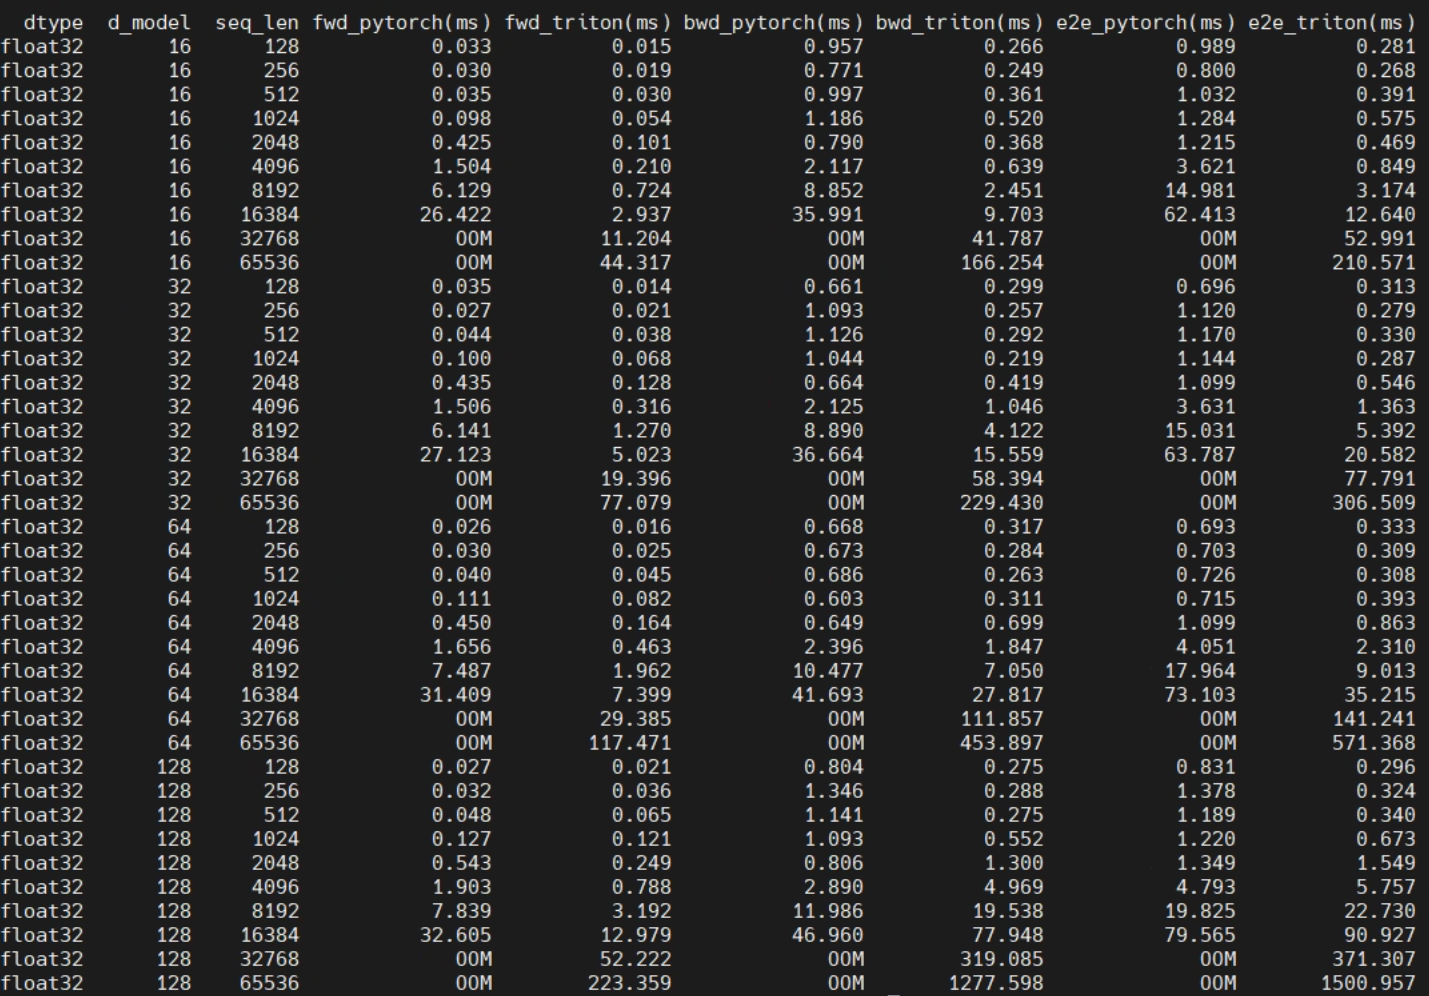

# 2.1.1 Benchmarking Distributed Applications

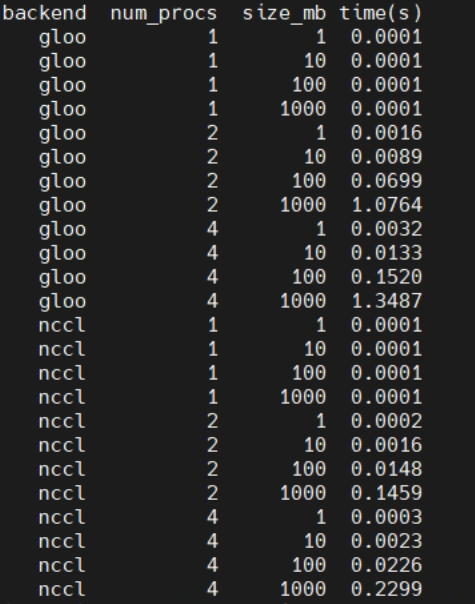

# 2.2.2 naive_ddp_benchmarking

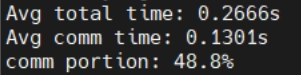

# 2.3.1 minimal_ddp_flat_benchmarking

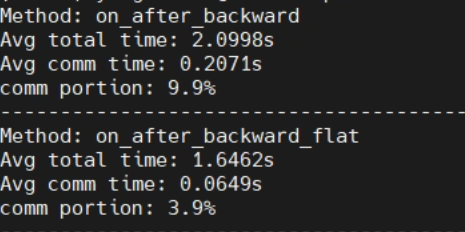

# 2.3.2 ddp_overlap_individual_parameters_benchmarking

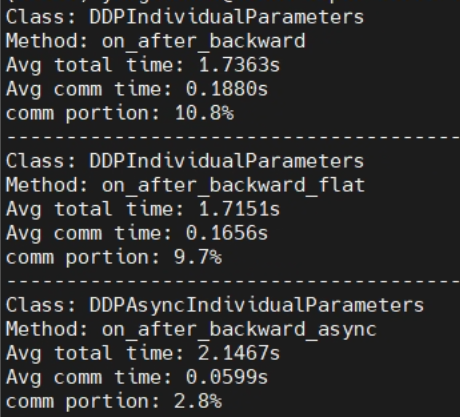

# 2.3.3 ddp_bucketed_benchmarking

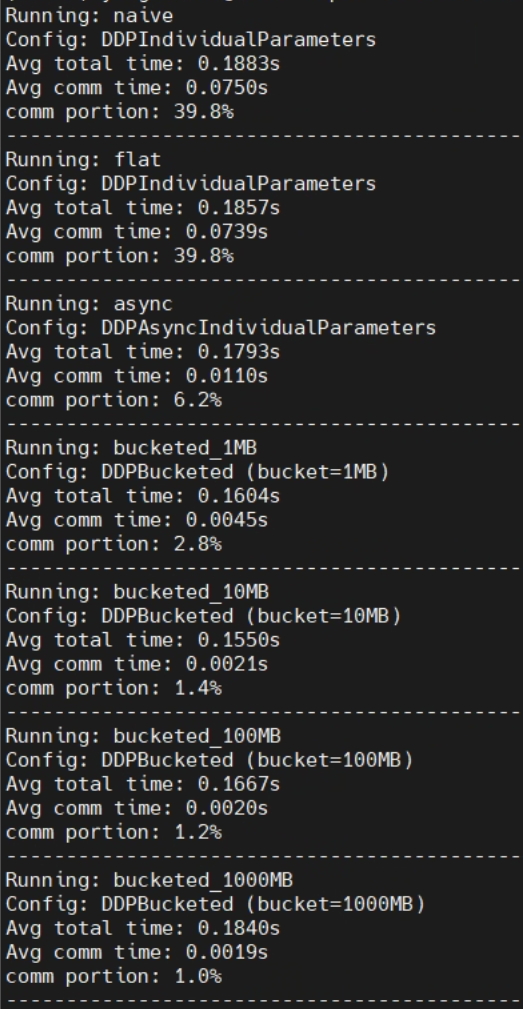

DDP Overhead 公式

  $$\text{overhead} = o + \frac{s}{n_b \cdot w}$$

  - s: 模型参数总大小 (bytes)
  - w: all-reduce 带宽 (bytes/s)
  - o: 每次通信的固定开销 (seconds)
  - n_b: 桶数量

  最优桶大小分析

  - 桶太小（1MB）：n_b 大，通信调用次数多，固定开销 o 累积无法完全被计算重叠
  - 桶太大（1000MB）：所有参数在一个桶里，必须等全部梯度算完才通信，退化为 flat
  版本，失去重叠优势
  - 最优点（~10MB）：在"减少调用次数"和"最大化重叠"之间取得平衡

  - 最优 bucket size： 由于 overhead 随 n_b 增大而减小，理论上 bucket
  越小越好。但受限于固定开销 o 不能完全被重叠，实际最优 bucket size 需要 o + b/w
  等于每个桶的计算时间。用你的 benchmark 结果来看，10MB 左右是最优的。